# External Data - Load, Explore & Align

**BUSI97075-2526 | Applied Trading Strategies**

## Purpose

Load all sheets from `DataTables Updated thru 18May26.xlsx`, understand what each one contains, and produce aligned, clean CSVs in `data/external/` that are ready for strategy construction in later tasks.

**Three things this notebook does:**
1. **Explore** — what is each sheet, how long does it run, how much is missing?
2. **Align** — reindex everything to the commodity trading calendar from Task 0 (`data/training/returns.csv`), forward-filling weekend/holiday gaps in level data before dropping non-trading days.
3. **Save** — one CSV per sheet, split into `data/external/training/` and `data/external/testing/`.

## Data types in the file

| Sheet | What it is | Type |
|---|---|---|
| FX SPOT | Daily spot rates for 15 G10 + EM FX pairs | Price levels → returns |
| ATM VOLS | 1M/3M/1Y ATM implied vols for 15 FX pairs (45 series) | Levels |
| 3M 25D RR | 3-month 25-delta risk reversals for 15 pairs (FX skew) | Levels |
| 3M DEPOSIT RATES | 3-month deposit rates for 16 currencies | Levels |
| 10Y YIELD | 10-year government bond yields for 8 countries | Levels |
| EQUITY INDICES | Daily closes for 9 major equity indices | Price levels → returns |
| COMDTY | Gold spot (XAU) and Brent front-month (CO1) | Price levels → returns |
| CREDIT SPREADS | CDX IG/HY and iTraxx EUR/Xover CDS spreads (4 series) | Levels (starts 2011) |
| JPM EASI | JPMorgan Economic Activity Surprise Index for 12 regions | Levels |
| IMM POSITIONING | CFTC IMM speculative positioning for 8 FX futures | Levels |
| 1M EUR FWD | EUR 1-month FX forward rate | Price levels → returns |

In [6]:
import os, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid']  = True
plt.rcParams['grid.alpha'] = 0.25

ROOT        = Path(os.path.abspath(''))
SOURCE_FILE = ROOT / 'source/DataTables Updated thru 18May26.xlsx'
TRAIN_END   = '2019-12-31'
TEST_START  = '2020-01-01'

# Derive the commodity trading calendar from Task 0's aligned returns.
# All external data will be reindexed to this calendar so every file
# shares exactly the same dates — no mismatches when joining signals.
_returns_train = pd.read_csv(ROOT / 'data/training/returns.csv',  index_col=0, parse_dates=True)
_returns_test  = pd.read_csv(ROOT / 'data/testing/returns.csv',   index_col=0, parse_dates=True)

TRADING_CALENDAR_TRAIN = _returns_train.index
TRADING_CALENDAR_TEST  = _returns_test.index
TRADING_CALENDAR_FULL  = TRADING_CALENDAR_TRAIN.append(TRADING_CALENDAR_TEST)

print(f'Trading calendar : {TRADING_CALENDAR_FULL[0].date()} → {TRADING_CALENDAR_FULL[-1].date()}')
print(f'Training days    : {len(TRADING_CALENDAR_TRAIN):,}  ({TRADING_CALENDAR_TRAIN[0].date()} → {TRADING_CALENDAR_TRAIN[-1].date()})')
print(f'Test days        : {len(TRADING_CALENDAR_TEST):,}   ({TRADING_CALENDAR_TEST[0].date()} → {TRADING_CALENDAR_TEST[-1].date()})')

xl     = pd.ExcelFile(SOURCE_FILE)
SHEETS = [s for s in xl.sheet_names if s not in ('BBG Formula', 'VARIABLES')]
print(f'Sheets           : {SHEETS}')

Trading calendar : 2005-10-05 → 2026-05-18
Training days    : 3,715  (2005-10-05 → 2019-12-31)
Test days        : 1,664   (2020-01-01 → 2026-05-18)
Sheets           : ['FX SPOT', 'ATM VOLS', '3M 25D RR', '3M DEPOSIT RATES', '10Y YIELD', 'EQUITY INDICES', 'COMDTY', 'CREDIT SPREADS', 'JPM EASI', 'IMM POSITIONING', '1M EUR FWD']


## 1. Load Raw Sheets & Overview

Load every sheet into a dictionary and produce a summary table showing date coverage, number of columns, and how much data is missing within the training window.

In [7]:
# Load every sheet into a dict, keeping NaNs intact so we can measure
# genuine missingness rather than masking it with early cleaning.
raw = {}
for sheet in SHEETS:
    df = pd.read_excel(xl, sheet_name=sheet, index_col=0, parse_dates=True)
    df.index = pd.to_datetime(df.index, errors='coerce')
    df = df[df.index.notna()].sort_index()
    df.index.name = 'Date'
    raw[sheet] = df

# Summary table — key things to check before touching the data:
#   Raw rows vs training days: the file includes weekends (~28% extra rows)
#   % missing in train: flags series that don't cover the full training window
records = []
for sheet, df in raw.items():
    window    = df.loc[TRADING_CALENDAR_TRAIN[0]:TRAIN_END]
    n_weekend = sum(d.weekday() >= 5 for d in df.index)
    records.append({
        'Sheet'            : sheet,
        'Cols'             : df.shape[1],
        'Raw rows (total)' : len(df),
        'Weekend rows'     : f'{n_weekend:,}',
        'First valid'      : df.apply(lambda c: c.first_valid_index()).min().date(),
        'Last valid'       : df.apply(lambda c: c.last_valid_index()).max().date(),
        '% missing (train)': f'{window.isna().mean().mean()*100:.1f}%',
        'Notes'            : 'starts Sep 2011'        if sheet == 'CREDIT SPREADS'   else
                             '5.5% structural gaps'   if sheet == '3M DEPOSIT RATES' else
                             '3-day pub lag applied'  if sheet == 'IMM POSITIONING'  else '',
    })

display(pd.DataFrame(records).set_index('Sheet'))

,Cols,Raw rows (total),Weekend rows,First valid,Last valid,% missing (train),Notes
Sheet,,,,,,,
FX SPOT,15,11878,"3,394",1993-11-10,2026-05-18,0.0%,
ATM VOLS,45,11878,"3,394",1993-12-28,2026-05-18,0.0%,
3M 25D RR,15,11878,"3,394",2003-07-09,2026-05-18,0.1%,
3M DEPOSIT RATES,16,11878,"3,394",1993-11-10,2026-05-18,5.5%,5.5% structural gaps
10Y YIELD,8,11878,"3,394",1993-11-10,2026-05-18,0.0%,
EQUITY INDICES,9,11878,"3,394",1993-11-10,2026-05-18,0.0%,
COMDTY,2,11878,"3,394",1993-11-10,2026-05-18,0.0%,
CREDIT SPREADS,4,11878,"3,394",2011-09-09,2026-05-18,41.8%,starts Sep 2011
JPM EASI,12,11878,"3,394",1996-01-02,2026-05-18,1.7%,


## 2. Per-Sheet Exploration

For each sheet: sample values, value range, and a cumulative plot so we can see what the series looks like over time.


  FX SPOT  (15 columns)
  Full range   : 1993-11-10 → 2026-05-18  (11,878 rows incl. weekends)
  Train window : 5,201 raw rows  |  missing: 0.0%
  Columns      : ['EURUSD CURNCY', 'GBPUSD Curncy', 'USDJPY Curncy', 'AUDUSD Curncy', 'USDNZD Curncy', 'CADUSD Curncy']  ...


,N,Mean,Std,Min,Max,% NaN
Column,,,,,,
EURUSD CURNCY,5201,1.2703,0.1276,1.0388,1.5991,0.0%
GBPUSD Curncy,5201,1.5743,0.2206,1.2033,2.1075,0.0%
USDJPY Curncy,5201,103.3438,13.5169,75.8200,125.6300,0.0%
AUDUSD Curncy,5201,0.8414,0.1188,0.6013,1.1020,0.0%
USDNZD Curncy,5201,1.3923,0.1478,1.1334,2.0298,0.0%
CADUSD Curncy,5201,0.8807,0.0985,0.6859,1.0865,0.0%
USDCHF Curncy,5201,1.0215,0.1142,0.7209,1.3256,0.0%
USDNOK Curncy,5201,6.8204,1.1967,4.9638,9.2273,0.0%
USDSEK Curncy,5201,7.5721,1.0165,5.8405,9.9582,0.0%


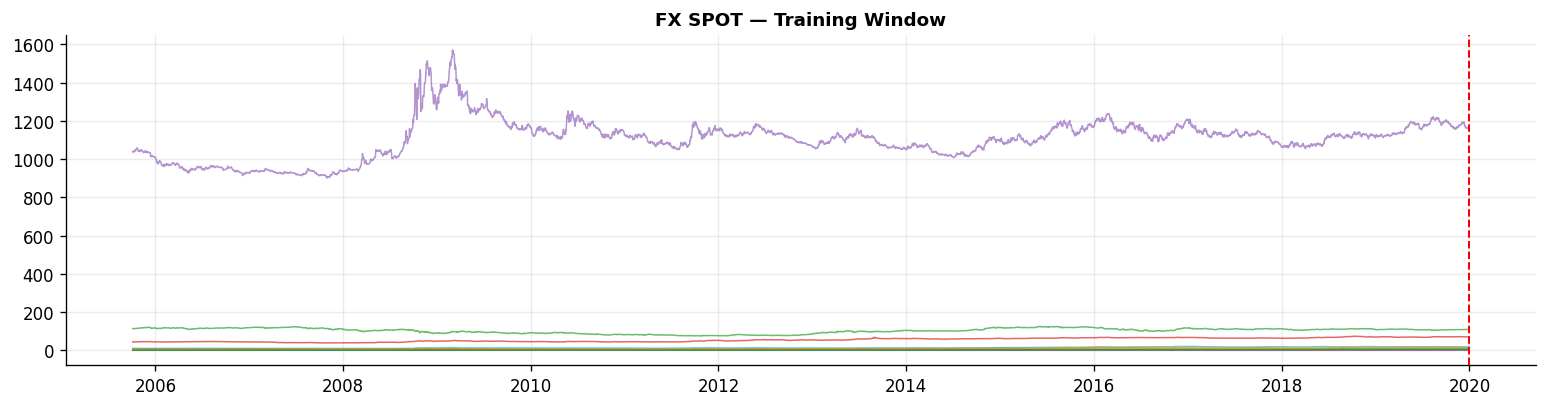


  ATM VOLS  (45 columns)
  Full range   : 1993-11-10 → 2026-05-18  (11,878 rows incl. weekends)
  Train window : 5,201 raw rows  |  missing: 0.0%
  Columns      : ['EURUSDV1M Curncy', 'EURUSDV3M Curncy', 'EURUSDV1Y Curncy', 'GBPUSDV1M Curncy', 'GBPUSDV3M Curncy', 'GBPUSDV1Y Curncy']  ...


,N,Mean,Std,Min,Max,% NaN
Column,,,,,,
EURUSDV1M Curncy,5201,9.2907,3.4605,3.8450,28.8850,0.0%
EURUSDV3M Curncy,5201,9.5019,3.2531,4.3675,24.6525,0.0%
EURUSDV1Y Curncy,5201,9.8692,2.9111,5.4650,19.9125,0.0%
GBPUSDV1M Curncy,5201,9.1728,3.4796,4.3350,29.6225,0.0%
GBPUSDV3M Curncy,5201,9.4548,3.1374,4.9000,24.9000,0.0%
GBPUSDV1Y Curncy,5201,9.8314,2.6709,5.6500,20.2150,0.0%
USDJPYV1M Curncy,5201,9.9544,3.4616,3.9225,38.4200,0.0%
USDJPYV3M Curncy,5201,10.0031,2.8813,4.9900,27.3875,0.0%
USDJPYV1Y Curncy,5201,10.3850,2.3691,6.3250,18.9075,0.0%


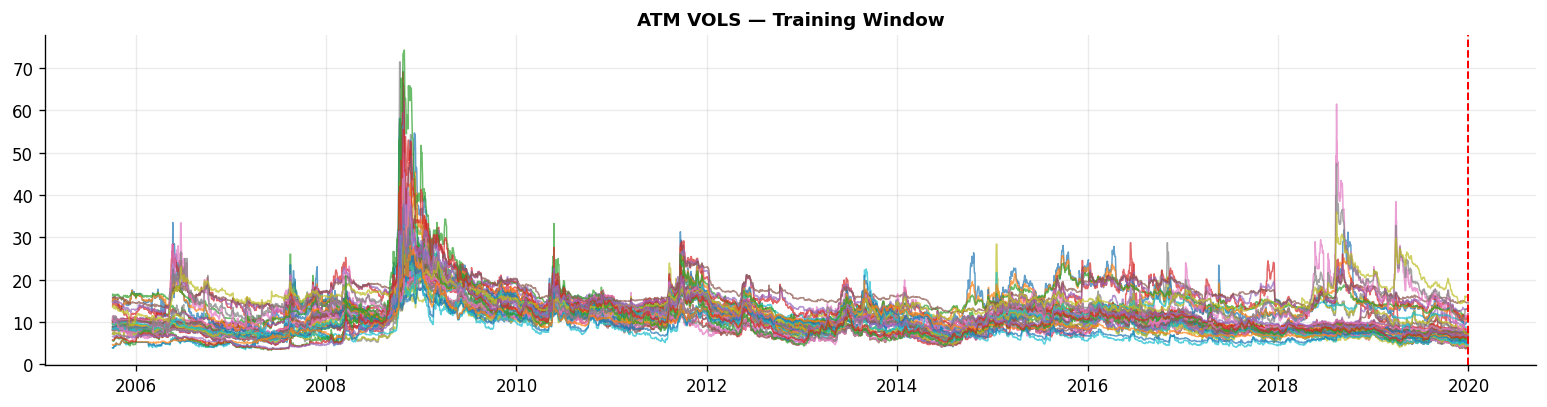


  3M 25D RR  (15 columns)
  Full range   : 1993-11-10 → 2026-05-18  (11,878 rows incl. weekends)
  Train window : 5,201 raw rows  |  missing: 0.1%
  Columns      : ['EURUSD25R3M CURNCY', 'GBPUSD25R3M CURNCY', 'USDJPY25R3M CURNCY', 'AUDUSD25R3M CURNCY', 'NZDUSD25R3M CURNCY', 'USDCAD25R3M CURNCY']  ...


,N,Mean,Std,Min,Max,% NaN
Column,,,,,,
EURUSD25R3M CURNCY,5201,-0.8393,0.9754,-4.3850,1.1250,0.0%
GBPUSD25R3M CURNCY,5201,-1.1017,0.9141,-6.3850,0.5375,0.0%
USDJPY25R3M CURNCY,5201,-1.4011,1.5712,-10.3550,1.4950,0.0%
AUDUSD25R3M CURNCY,5201,-1.7982,1.2776,-7.9000,-0.0750,0.0%
NZDUSD25R3M CURNCY,5201,-1.8168,1.2147,-7.6350,-0.2000,0.0%
USDCAD25R3M CURNCY,5201,0.7764,0.7206,-0.6200,4.1650,0.0%
USDCHF25R3M CURNCY,5201,-0.1231,0.7879,-3.0425,2.3400,0.0%
USDNOK25R3M CURNCY,5201,0.9854,0.8862,-0.6732,3.7850,0.0%
USDSEK25R3M CURNCY,5201,0.9553,0.8684,-1.5048,3.6075,0.0%


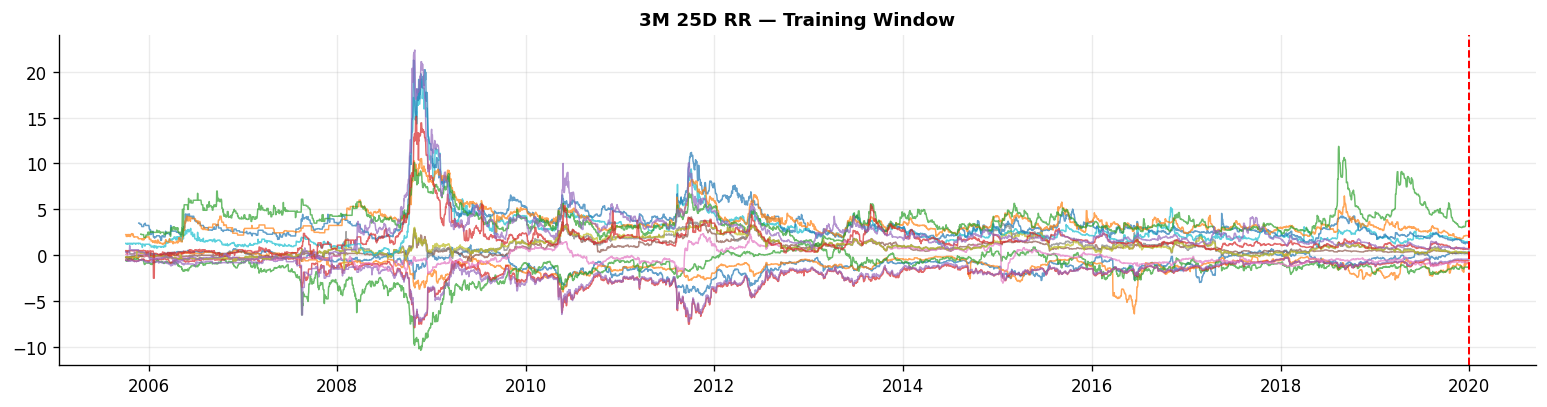


  3M DEPOSIT RATES  (16 columns)
  Full range   : 1993-11-10 → 2026-05-18  (11,878 rows incl. weekends)
  Train window : 5,201 raw rows  |  missing: 5.5%
  Columns      : ['USDRC CURNCY', 'EUDRC CURNCY', 'BPDRC CURNCY', 'JYDRC CURNCY', 'ADDRC CURNCY', 'NDDRC CURNCY']  ...


,N,Mean,Std,Min,Max,% NaN
Column,,,,,,
USDRC CURNCY,5201,1.7052,1.7364,0.175,6.130,0.0%
EUDRC CURNCY,5201,1.0611,1.6672,-0.465,5.500,0.0%
BPDRC CURNCY,5201,1.7511,2.0003,0.250,6.835,0.0%
JYDRC CURNCY,5201,0.1633,0.3515,-0.650,1.750,0.0%
ADDRC CURNCY,5201,3.7935,1.8037,0.825,8.300,0.0%
NDDRC CURNCY,5201,3.9930,2.2495,1.210,9.800,0.0%
CDDRC CURNCY,5201,1.7739,1.2732,0.250,5.125,0.0%
SFDRC CURNCY,5201,0.2939,1.1266,-2.295,3.565,0.0%
NKDRC CURNCY,5201,2.2955,1.4821,0.605,7.630,0.0%


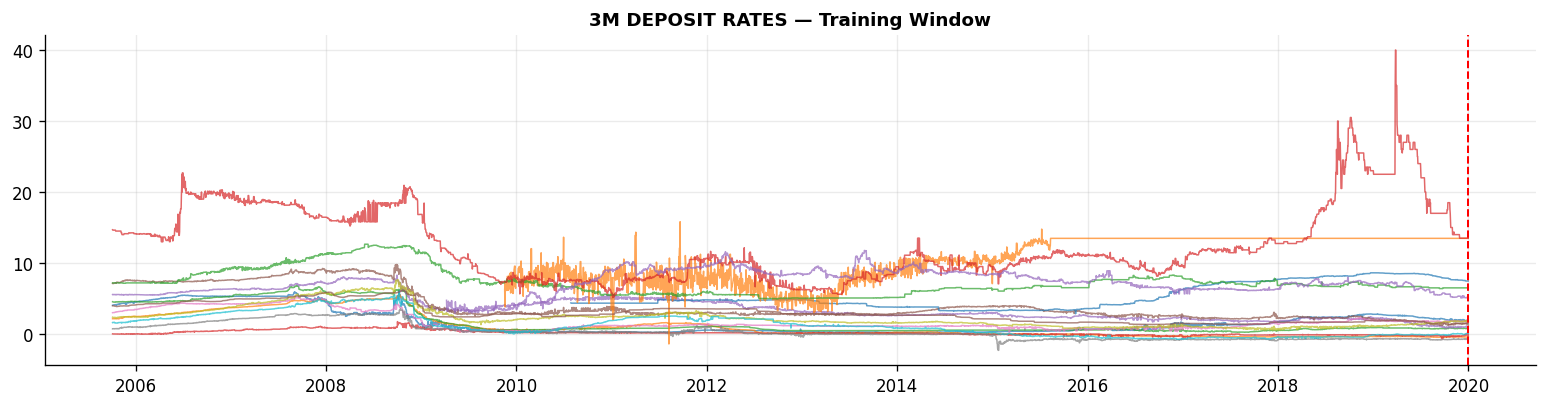


  10Y YIELD  (8 columns)
  Full range   : 1993-11-10 → 2026-05-18  (11,878 rows incl. weekends)
  Train window : 5,201 raw rows  |  missing: 0.0%
  Columns      : ['USGG10YR INDEX', 'GJGB10 INDEX', 'GUKG10 INDEX', 'GDBR10 INDEX', 'GFRN10 INDEX', 'GBTPGR10 INDEX']  ...


,N,Mean,Std,Min,Max,% NaN
Column,,,,,,
USGG10YR INDEX,5201,2.9011,0.9884,1.3579,5.2928,0.0%
GJGB10 INDEX,5201,0.8015,0.6401,-0.2870,2.0090,0.0%
GUKG10 INDEX,5201,2.6970,1.3628,0.4060,5.5480,0.0%
GDBR10 INDEX,5201,1.9132,1.5147,-0.7140,4.6810,0.0%
GFRN10 INDEX,5201,2.2928,1.4492,-0.4380,4.8440,0.0%
GBTPGR10 INDEX,5201,3.5197,1.3809,0.8100,7.2610,0.0%
GSPG10YR INDEX,5201,3.2992,1.6408,0.0350,7.6210,0.0%
GACGB10 INDEX,5201,3.9788,1.4754,0.8760,6.7860,0.0%


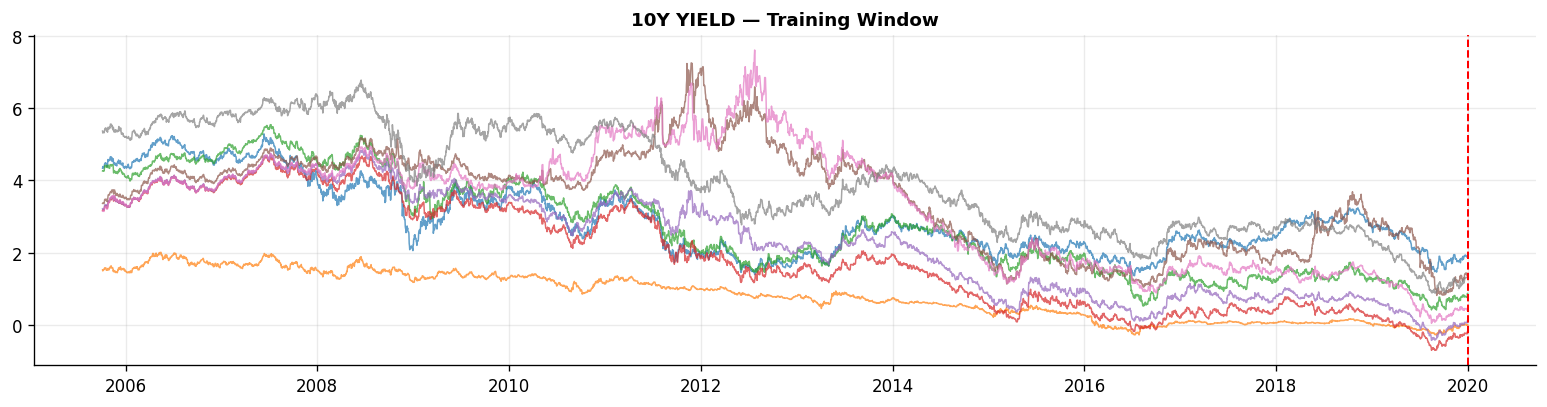


  EQUITY INDICES  (9 columns)
  Full range   : 1993-11-10 → 2026-05-18  (11,878 rows incl. weekends)
  Train window : 5,201 raw rows  |  missing: 0.0%
  Columns      : ['SPX INDEX', 'NKY INDEX', 'UKX INDEX', 'SX5E INDEX', 'AS51 INDEX', 'MEXBOL INDEX']  ...


,N,Mean,Std,Min,Max,% NaN
Column,,,,,,
SPX INDEX,5201,1746.5444,605.9357,676.530,3240.020,0.0%
NKY INDEX,5201,15167.4548,4597.6430,7054.980,24270.620,0.0%
UKX INDEX,5201,6228.7678,862.0899,3512.090,7877.450,0.0%
SX5E INDEX,5201,3180.2317,556.0017,1809.980,4557.570,0.0%
AS51 INDEX,5201,5226.7977,758.3984,3145.457,6863.998,0.0%
MEXBOL INDEX,5201,37122.6329,9256.1770,14821.100,51713.380,0.0%
IBOV INDEX,5201,60046.0487,16389.5405,28344.080,117203.200,0.0%
KOSPI INDEX,5201,1874.8363,324.2481,938.750,2598.190,0.0%
HSI INDEX,5201,22481.6898,4023.8574,11015.840,33154.120,0.0%


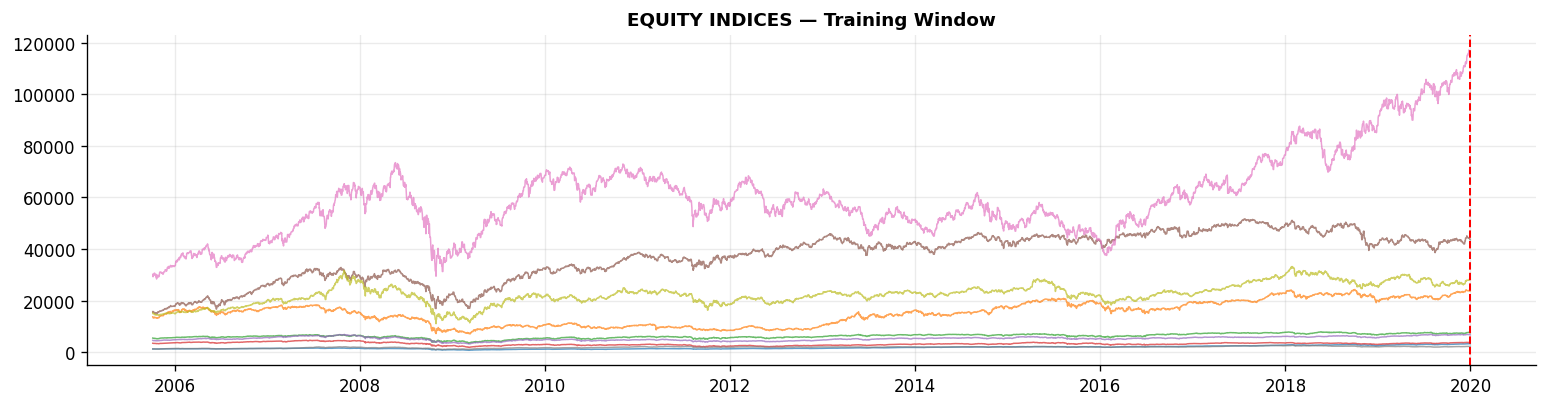


  COMDTY  (2 columns)
  Full range   : 1993-11-10 → 2026-05-18  (11,878 rows incl. weekends)
  Train window : 5,201 raw rows  |  missing: 0.0%
  Columns      : ['XAU CURNCY', 'CO1 COMDTY']


,N,Mean,Std,Min,Max,% NaN
Column,,,,,,
XAU CURNCY,5201,1175.6408,317.5152,456.90,1900.20,0.0%
CO1 COMDTY,5201,78.2511,24.7141,27.88,146.08,0.0%


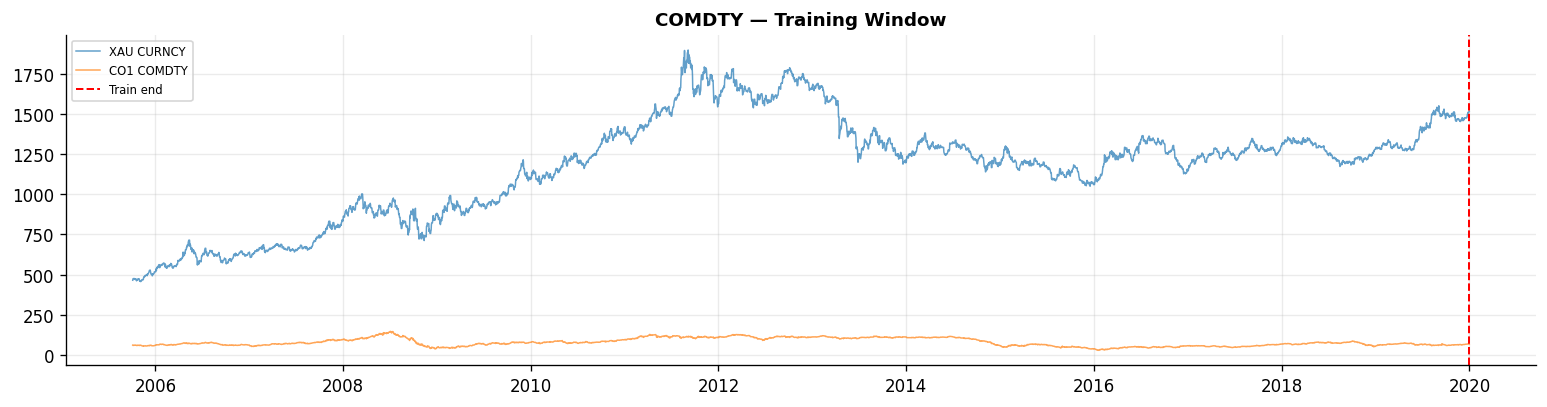


  CREDIT SPREADS  (4 columns)
  Full range   : 1993-11-10 → 2026-05-18  (11,878 rows incl. weekends)
  Train window : 5,201 raw rows  |  missing: 41.8%
  Columns      : ['CDX IG CDSI GEN 5Y Corp', 'CDX HY CDSI GEN 5Y CORP', 'ITRX EUR CDSI GEN 5Y CORP', 'ITRX XOVER CDSI GEN 5Y CORP']


,N,Mean,Std,Min,Max,% NaN
Column,,,,,,
CDX IG CDSI GEN 5Y Corp,3036,74.9086,19.7477,43.948,151.500,41.6%
CDX HY CDSI GEN 5Y CORP,3036,104.2398,4.3541,86.250,109.806,41.6%
ITRX EUR CDSI GEN 5Y CORP,3003,82.4182,33.6428,42.847,208.500,42.3%
ITRX XOVER CDSI GEN 5Y CORP,3036,357.2542,138.0301,204.377,845.000,41.6%


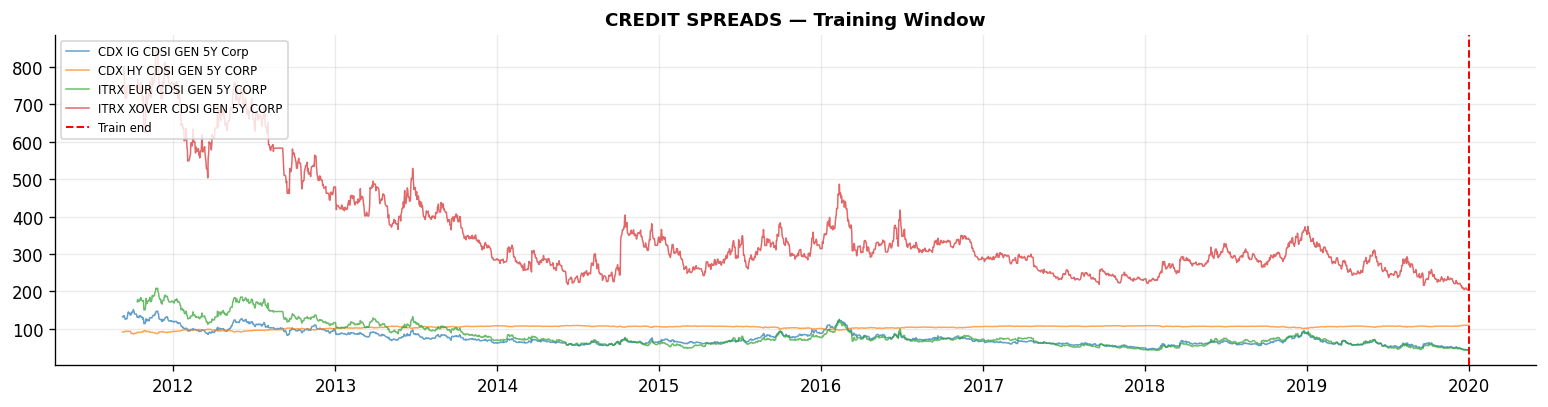


  JPM EASI  (12 columns)
  Full range   : 1993-11-10 → 2026-05-18  (11,878 rows incl. weekends)
  Train window : 5,201 raw rows  |  missing: 1.7%
  Columns      : ['JPEASIGL INDEX', 'JPEASIUS INDEX', 'JPEASIEU INDEX', 'JPEASICN INDEX', 'JPEASISE INDEX', 'JPEASIAU INDEX']  ...


,N,Mean,Std,Min,Max,% NaN
Column,,,,,,
JPEASIGL INDEX,4129,0.1749,8.5956,-36.400,26.800,20.6%
JPEASIUS INDEX,5201,-1.4957,13.8272,-43.333,40.625,0.0%
JPEASIEU INDEX,5201,1.0383,18.5475,-51.430,51.520,0.0%
JPEASICN INDEX,5201,3.6469,24.7700,-66.670,100.000,0.0%
JPEASISE INDEX,5201,0.2945,29.1791,-87.500,83.330,0.0%
JPEASIAU INDEX,5201,-2.7480,22.9323,-80.000,85.710,0.0%
JPEASINO INDEX,5201,4.9096,35.3731,-100.000,100.000,0.0%
JPEASICA INDEX,5201,1.2853,34.5616,-100.000,100.000,0.0%
JPEASIJP INDEX,5201,0.4647,38.5499,-100.000,100.000,0.0%


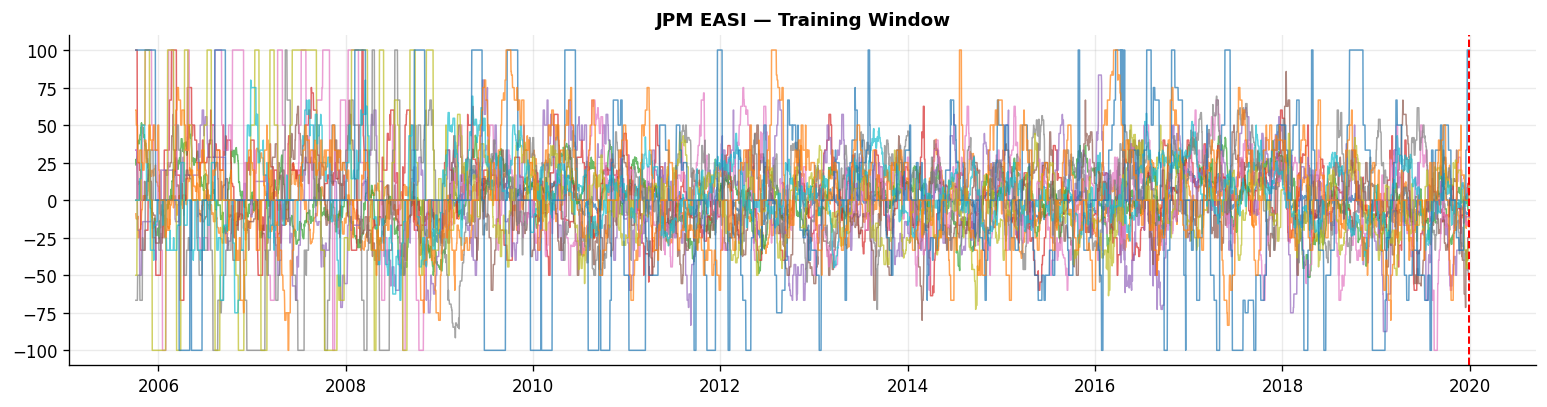


  IMM POSITIONING  (8 columns)
  Full range   : 1993-11-10 → 2026-05-18  (11,878 rows incl. weekends)
  Train window : 5,201 raw rows  |  missing: 0.0%
  Columns      : ['IMMBENCN Index', 'IMMBENCN Index.1', 'IMM6ANCN Index', 'IMM6MNCN Index', 'IMMPFNCN Index', 'IMM3CNCN Index']  ...


,N,Mean,Std,Min,Max,% NaN
Column,,,,,,
IMMBENCN Index,5201,-19605.9254,79431.5188,-226560.0,151476.0,0.0%
IMMBENCN Index.1,5201,-19605.9254,79431.5188,-226560.0,151476.0,0.0%
IMM6ANCN Index,5201,14101.4747,43348.5233,-76851.0,103376.0,0.0%
IMM6MNCN Index,5201,35656.3438,58420.4601,-89342.0,158216.0,0.0%
IMMPFNCN Index,5201,-19388.4376,78657.9740,-225776.0,147318.0,0.0%
IMM3CNCN Index,5201,2635.5328,38251.1749,-99109.0,111881.0,0.0%
IMM6ZNCN Index,5201,4428.0440,13129.2169,-42474.0,35981.0,0.0%
IMM4SNCN Index,5201,-8712.7787,17271.7345,-79331.0,27640.0,0.0%


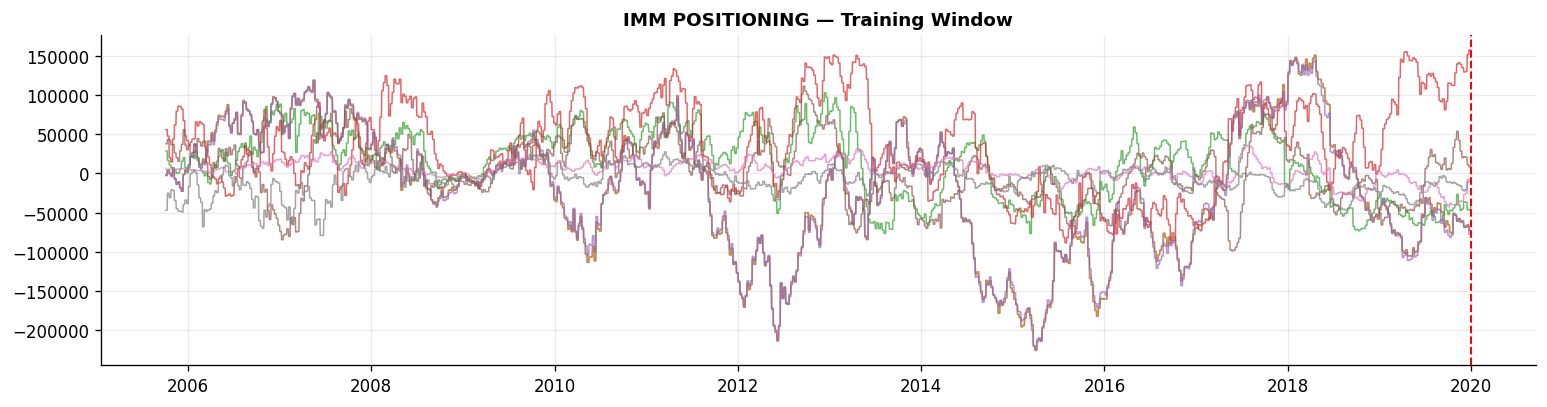


  1M EUR FWD  (1 columns)
  Full range   : 1993-11-10 → 2026-05-18  (11,878 rows incl. weekends)
  Train window : 5,201 raw rows  |  missing: 0.0%
  Columns      : ['EUR1M BGN Curncy']


,N,Mean,Std,Min,Max,% NaN
Column,,,,,,
EUR1M BGN Curncy,5201,1.2711,0.1267,1.041,1.5972,0.0%


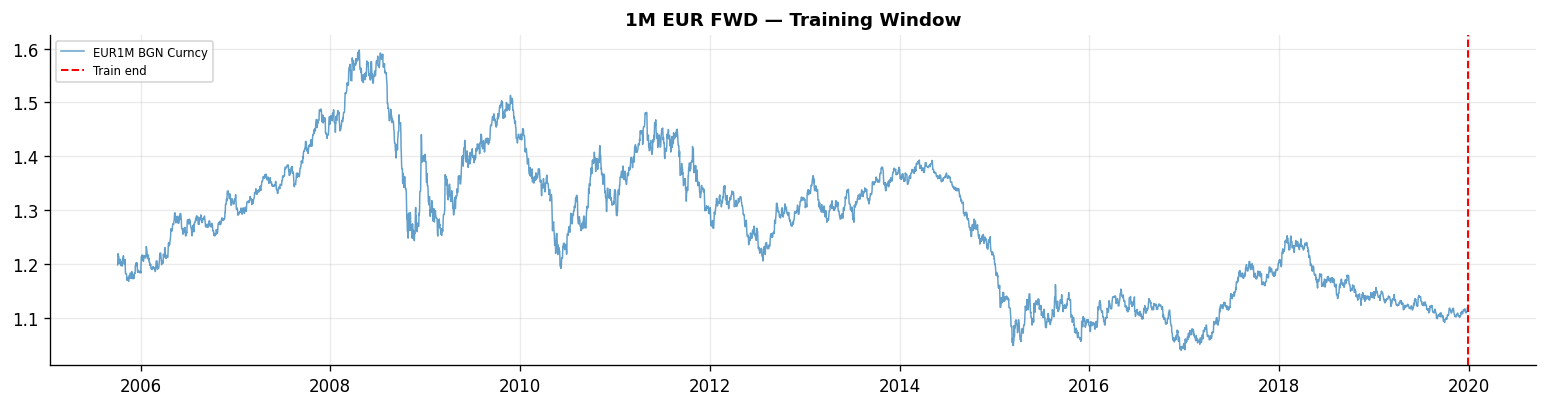

In [8]:
for sheet, df in raw.items():
    train_window = df.loc[TRADING_CALENDAR_TRAIN[0]:TRAIN_END]

    print(f'\n{"="*70}')
    print(f'  {sheet}  ({df.shape[1]} columns)')
    print(f'{"="*70}')
    print(f'  Full range   : {df.index[0].date()} → {df.index[-1].date()}  ({len(df):,} rows incl. weekends)')
    print(f'  Train window : {len(train_window):,} raw rows  |  missing: {train_window.isna().mean().mean()*100:.1f}%')
    print(f'  Columns      : {df.columns.tolist()[:6]}{"  ..." if df.shape[1] > 6 else ""}')

    # Per-column stats over the training window only.
    # Vol, min/max help spot outliers or stale values before alignment.
    stats_rows = []
    for col in df.columns:
        s = train_window[col].dropna()
        if len(s) == 0:
            continue
        stats_rows.append({
            'Column': col,
            'N'     : len(s),
            'Mean'  : round(s.mean(), 4),
            'Std'   : round(s.std(),  4),
            'Min'   : round(s.min(),  4),
            'Max'   : round(s.max(),  4),
            '% NaN' : f'{train_window[col].isna().mean()*100:.1f}%',
        })
    display(pd.DataFrame(stats_rows).set_index('Column'))

    # Time-series plot — visual check for regime breaks, data gaps, or
    # suspicious flat periods that wouldn't show up in summary stats.
    fig, ax = plt.subplots(figsize=(13, 3.5))
    for col in df.columns:
        s = train_window[col].dropna()
        ax.plot(s.index, s.values, lw=0.9, alpha=0.7,
                label=col if df.shape[1] <= 6 else None)
    ax.axvline(pd.Timestamp(TRAIN_END), color='red', lw=1.2,
               linestyle='--', label='Train end')
    ax.set_title(f'{sheet} — Training Window', fontsize=11, fontweight='bold')
    if df.shape[1] <= 6:
        ax.legend(fontsize=7, loc='upper left')
    ax.spines[['top', 'right']].set_visible(False)
    fig.tight_layout()
    plt.show()

## 3. Alignment to Commodity Trading Calendar

The DataTables file includes weekends and some non-trading holidays — it has ~5,200 rows in the training window vs 3,715 in the commodity data. We need every external series on exactly the same dates as `data/training/returns.csv`.

**Process per sheet:**
1. **Forward-fill** the raw series up to 5 days — carries Friday's value into Saturday/Sunday so that when we drop those days the most recent observation is preserved. This is standard practice for rate/vol/level data that doesn't trade on weekends.
2. **Reindex** to the commodity trading calendar — drops all dates not in the commodity calendar (including all weekends), and introduces NaN for any commodity trading day the external source didn't cover.
3. For **price-level series** (FX SPOT, EQUITY INDICES, COMDTY, 1M EUR FWD) we then compute daily % returns with `pct_change()`.
4. Level series (vols, rates, yields, spreads, positioning) are saved as-is after alignment.

**Dating conventions and look-ahead bias notes:**

| Sheet | Dating assumption | Action taken |
|---|---|---|
| FX SPOT, ATM VOLS, 3M 25D RR, 10Y YIELD, EQUITY INDICES, COMDTY, 1M EUR FWD | Bloomberg end-of-day marks — available at close on the indexed date | None — used as-is |
| 3M DEPOSIT RATES | Quoted rates, available intraday | None — used as-is |
| CREDIT SPREADS | EOD marks, available same day. **Starts Sep 2011** — NaN for 2005–2011 in training. Do not interpolate across this gap | None — NaN preserved |
| JPM EASI | Daily economic activity surprise index. Updates when economic data is released (Bloomberg timestamps releases on the release date). Treated as available at close on the indexed date | None — used as-is |
| **IMM POSITIONING** | **CFTC COT data is indexed as the Tuesday as-of date, but CFTC publishes on Friday 3:30pm ET. Using Tuesday's value before Friday is 3 days of look-ahead. Fix: shift forward 3 business days.** | `.shift(3)` applied after alignment |

In [9]:
# Price-level sheets: we compute pct_change() to get daily returns.
# All other sheets are rates/vols/spreads/indices — kept as levels.
PRICE_SHEETS = {'FX SPOT', 'EQUITY INDICES', 'COMDTY', '1M EUR FWD'}

def align_to_calendar(df: pd.DataFrame, calendar: pd.DatetimeIndex) -> pd.DataFrame:
    # ffill(limit=5) carries the last known value across weekends/holidays
    # (max 5 days covers a full week without bridging genuine data gaps).
    # reindex then drops every date outside the commodity trading calendar.
    return df.ffill(limit=5).reindex(calendar)

aligned = {}
returns = {}

for sheet, df in raw.items():
    al = align_to_calendar(df, TRADING_CALENDAR_FULL)
    aligned[sheet] = al
    if sheet in PRICE_SHEETS:
        returns[sheet] = al.pct_change()

# IMM POSITIONING — publication lag correction.
# CFTC COT data is recorded as-of Tuesday close but published Friday 3:30pm ET.
# Bloomberg stores the value against the Tuesday as-of date, so without this
# shift a backtest would use positioning data 3 days before it was public.
# Shifting forward 3 business days means the value first appears on Friday —
# the earliest a live trader could act on it.
aligned['IMM POSITIONING'] = aligned['IMM POSITIONING'].shift(3)

print('Alignment check — residual NaN% after alignment to trading calendar:\n')
print(f'{"Sheet":<22}  {"Train rows":>10}  {"NaN% train":>11}  {"NaN% test":>10}')
print('-' * 60)
for sheet, df in aligned.items():
    tr     = df.loc[TRADING_CALENDAR_TRAIN]
    te     = df.loc[TRADING_CALENDAR_TEST]
    note   = '  ← starts Sep 2011'   if sheet == 'CREDIT SPREADS'  else \
             '  ← 3-day pub lag'     if sheet == 'IMM POSITIONING'  else ''
    print(f'{sheet:<22}  {len(tr):>10,}  {tr.isna().mean().mean()*100:>10.1f}%'
          f'  {te.isna().mean().mean()*100:>9.1f}%{note}')

Alignment check — residual NaN% after alignment to trading calendar:

Sheet                   Train rows   NaN% train   NaN% test
------------------------------------------------------------
FX SPOT                      3,715         0.0%        0.0%
ATM VOLS                     3,715         0.0%        0.0%
3M 25D RR                    3,715         0.1%        0.0%
3M DEPOSIT RATES             3,715         5.5%        0.0%
10Y YIELD                    3,715         0.0%        0.0%
EQUITY INDICES               3,715         0.0%        0.0%
COMDTY                       3,715         0.0%        0.0%
CREDIT SPREADS               3,715        41.8%        0.0%  ← starts Sep 2011
JPM EASI                     3,715         1.7%        0.0%
IMM POSITIONING              3,715         0.1%        0.0%  ← 3-day pub lag
1M EUR FWD                   3,715         0.0%        0.0%


## 4. Save to `data/external/`

One CSV per sheet, split into `training/` and `testing/` subfolders. Price-level sheets are saved **twice** — once as levels (e.g. `fx_spot_levels.csv`) and once as returns (e.g. `fx_spot_returns.csv`) so downstream tasks can use either form without recomputing.

In [10]:
SLUG = {
    'FX SPOT'          : 'fx_spot',
    'ATM VOLS'         : 'atm_vols',
    '3M 25D RR'        : 'risk_reversals',
    '3M DEPOSIT RATES' : 'deposit_rates',
    '10Y YIELD'        : 'bond_yields_10y',
    'EQUITY INDICES'   : 'equity_indices',
    'COMDTY'           : 'comdty',
    'CREDIT SPREADS'   : 'credit_spreads',
    'JPM EASI'         : 'jpm_easi',
    'IMM POSITIONING'  : 'imm_positioning',
    '1M EUR FWD'       : 'eur_1m_fwd',
}

for split, calendar in [('training', TRADING_CALENDAR_TRAIN),
                         ('testing',  TRADING_CALENDAR_TEST)]:
    out_dir = ROOT / 'data' / 'external' / split
    out_dir.mkdir(parents=True, exist_ok=True)

    for sheet, df in aligned.items():
        slug   = SLUG[sheet]
        subset = df.loc[calendar]

        # _levels: the aligned level series (all sheets).
        subset.to_csv(out_dir / f'{slug}_levels.csv')

        # _returns: daily pct_change for price-level sheets.
        # Saved separately so downstream tasks can use either form
        # without recomputing — levels for signal construction,
        # returns for performance attribution or cross-asset factors.
        if sheet in PRICE_SHEETS:
            returns[sheet].loc[calendar].to_csv(out_dir / f'{slug}_returns.csv')

# Manifest
print('Saved:\n')
for split in ('training', 'testing'):
    out_dir = ROOT / 'data' / 'external' / split
    files   = sorted(out_dir.glob('*.csv'))
    print(f'  data/external/{split}/  ({len(files)} files)')
    for f in files:
        df_f = pd.read_csv(f, index_col=0)
        print(f'    {f.name:<42}  {df_f.shape[0]:>5} rows × {df_f.shape[1]:>3} cols')
    print()

Saved:

  data/external/training/  (15 files)
    atm_vols_levels.csv                          3715 rows ×  45 cols
    bond_yields_10y_levels.csv                   3715 rows ×   8 cols
    comdty_levels.csv                            3715 rows ×   2 cols
    comdty_returns.csv                           3715 rows ×   2 cols
    credit_spreads_levels.csv                    3715 rows ×   4 cols
    deposit_rates_levels.csv                     3715 rows ×  16 cols
    equity_indices_levels.csv                    3715 rows ×   9 cols
    equity_indices_returns.csv                   3715 rows ×   9 cols
    eur_1m_fwd_levels.csv                        3715 rows ×   1 cols
    eur_1m_fwd_returns.csv                       3715 rows ×   1 cols
    fx_spot_levels.csv                           3715 rows ×  15 cols
    fx_spot_returns.csv                          3715 rows ×  15 cols
    imm_positioning_levels.csv                   3715 rows ×   8 cols
    jpm_easi_levels.csv                     